In [1]:
import numpy as np
import pandas as pd # 데이타베이스, 엑셀 이런걸 할 수 있는 패키지

se = pd.Series([1, 2, np.nan, 4])   # np.nan은 결측값
se

0    1.0
1    2.0
2    NaN
3    4.0
dtype: float64

In [ ]:
se.isna()    # np.nan이 포함된 세번째 항목만 True를 반환

윗 코드는 아래처럼 확장될 수 있다.

In [9]:
print(se.isna())    # np.nan이 포함된 세번째 항목만 True를 반환
for i in range(se.size):
    if(se.isna()[i]):
        print('숫자가 아니다')
    else:
        print('숫자네')

0    False
1    False
2     True
3    False
dtype: bool
숫자네
숫자네
숫자가 아니다
숫자네


In [11]:
print(se[1])

2.0


In [12]:
import pandas as pd
import numpy as np

data = [1, 2, np.nan, 4]
indexed_se = pd.Series(data, index = ['a', 'b', 'c', 'd'])
print(indexed_se)

a    1.0
b    2.0
c    NaN
d    4.0
dtype: float64


In [13]:
print(indexed_se['a'])

1.0


In [18]:
month_se = pd.Series(['1월', '2월', '3월', '4월'])
income_se = pd.Series([9500, 6200, 6050, 7000])
expenses_se = pd.Series([5040, 2350, 2300, 4800])
df = pd.DataFrame( {'월': month_se, '수익': income_se,
                   '지출' : expenses_se})
df    # print(df)를 이용해서 출력형식을 비교해 보자


,월,수익,지출
0,1월,9500,5040
1,2월,6200,2350
2,3월,6050,2300
3,4월,7000,4800


In [17]:
print(df)

    월    수익    지출
0  1월  9500  5040
1  2월  6200  2350
2  3월  6050  2300
3  4월  7000  4800


In [19]:
# 판다스 Series를 이용하여 최대 수익 월을 출력하기
m_idx = np.argmax(income_se)  # 넘파이의 argmax() 사용
print('최대 수익이 발생한 월:', month_se[m_idx])

최대 수익이 발생한 월: 1월


In [20]:
# 판다스 Series를 이용하여 최대 수익 월을 출력하기
m_idx = np.argmax(income_se)  # 넘파이의 argmax() 사용
print('최대 수익이 발생한 월:', month_se[m_idx])

최대 수익이 발생한 월: 1월


In [26]:
print('월 최대 수익:', income_se.max(),', 월 평균 수익:', income_se.mean(),', 소득 총계:', income_se.sum())

월 최대 수익: 9500 , 월 평균 수익: 7187.5 , 소득 총계: 28750


In [30]:
file = './vehicle_prod.csv'
df = pd.read_csv(file, index_col=0)
df

,2007,2008,2009,2010,2011
China,7.71,7.95,11.96,15.84,16.33
EU,19.02,17.71,15.00,16.70,17.48
US,10.47,8.45,5.58,7.60,8.40
Japan,10.87,10.83,7.55,9.09,7.88
Korea,4.04,3.78,3.45,4.20,4.62
Mexico,2.01,2.05,1.50,2.25,2.54


**문자임에 주의!**


In [33]:
df.index

Index(['China', 'EU', 'US', 'Japan', 'Korea', 'Mexico'], dtype='object')

In [36]:
df.columns

Index(['2007', '2008', '2009', '2010', '2011'], dtype='object')

In [39]:
df.index[2]

'US'

In [40]:
df.columns[0]

'2007'

In [49]:
df['2007']

China      7.71
EU        19.02
US        10.47
Japan     10.87
Korea      4.04
Mexico     2.01
Name: 2007, dtype: float64

In [50]:
df.columns.tolist()

['2007', '2008', '2009', '2010', '2011']

In [53]:
list_2=df['2007'].to_list()
list_2

[7.71, 19.02, 10.47, 10.87, 4.04, 2.01]

In [54]:
list_2=df['2007'].to_list()
list_2[0]

7.71

In [56]:
df['2007']+df['2008']+df['2009']+df['2010']+df['2011']

China     59.79
EU        85.91
US        40.50
Japan     46.22
Korea     20.09
Mexico    10.35
dtype: float64

In [57]:
df['total']=df.sum(axis=1)

In [58]:
df

,2007,2008,2009,2010,2011,total
China,7.71,7.95,11.96,15.84,16.33,59.79
EU,19.02,17.71,15.00,16.70,17.48,85.91
US,10.47,8.45,5.58,7.60,8.40,40.50
Japan,10.87,10.83,7.55,9.09,7.88,46.22
Korea,4.04,3.78,3.45,4.20,4.62,20.09
Mexico,2.01,2.05,1.50,2.25,2.54,10.35


In [61]:
df['mean'] = df[['2007', '2008', '2009', '2010', '2011']].mean(axis=1)
df


,2007,2008,2009,2010,2011,total,mean
China,7.71,7.95,11.96,15.84,16.33,59.79,11.958
EU,19.02,17.71,15.00,16.70,17.48,85.91,17.182
US,10.47,8.45,5.58,7.60,8.40,40.50,8.100
Japan,10.87,10.83,7.55,9.09,7.88,46.22,9.244
Korea,4.04,3.78,3.45,4.20,4.62,20.09,4.018
Mexico,2.01,2.05,1.50,2.25,2.54,10.35,2.070


In [63]:
df.drop('2007', inplace=True, axis=1)
print(df)       # 이전에 구한 total, mean 값이 나타남

         2008   2009   2010   2011  total    mean
China    7.95  11.96  15.84  16.33  59.79  11.958
EU      17.71  15.00  16.70  17.48  85.91  17.182
US       8.45   5.58   7.60   8.40  40.50   8.100
Japan   10.83   7.55   9.09   7.88  46.22   9.244
Korea    3.78   3.45   4.20   4.62  20.09   4.018
Mexico   2.05   1.50   2.25   2.54  10.35   2.070


In [65]:
print(df)

         2008   2009   2010   2011  total    mean
China    7.95  11.96  15.84  16.33  59.79  11.958
EU      17.71  15.00  16.70  17.48  85.91  17.182
US       8.45   5.58   7.60   8.40  40.50   8.100
Japan   10.83   7.55   9.09   7.88  46.22   9.244
Korea    3.78   3.45   4.20   4.62  20.09   4.018
Mexico   2.05   1.50   2.25   2.54  10.35   2.070


In [68]:
new_df=df.drop('2008', inplace=False, axis=1)
print(new_df)       # 이전에 구한 total, mean 값이 나타남
df

         2009   2010   2011  total    mean
China   11.96  15.84  16.33  59.79  11.958
EU      15.00  16.70  17.48  85.91  17.182
US       5.58   7.60   8.40  40.50   8.100
Japan    7.55   9.09   7.88  46.22   9.244
Korea    3.45   4.20   4.62  20.09   4.018
Mexico   1.50   2.25   2.54  10.35   2.070


,2008,2009,2010,2011,total,mean
China,7.95,11.96,15.84,16.33,59.79,11.958
EU,17.71,15.00,16.70,17.48,85.91,17.182
US,8.45,5.58,7.60,8.40,40.50,8.100
Japan,10.83,7.55,9.09,7.88,46.22,9.244
Korea,3.78,3.45,4.20,4.62,20.09,4.018
Mexico,2.05,1.50,2.25,2.54,10.35,2.070


In [3]:
import pandas as pd
import numpy as np
file = './vehicle_prod.csv'
df = pd.read_csv(file)
df

,Unnamed: 0,2007,2008,2009,2010,2011
0,China,7.71,7.95,11.96,15.84,16.33
1,EU,19.02,17.71,15.00,16.70,17.48
2,US,10.47,8.45,5.58,7.60,8.40
3,Japan,10.87,10.83,7.55,9.09,7.88
4,Korea,4.04,3.78,3.45,4.20,4.62
5,Mexico,2.01,2.05,1.50,2.25,2.54


아래는 조금 어렵다.

In [4]:
total=df.select_dtypes(np.number).sum().rename()
print(total)
df.loc['total']=total
df

2007    54.12
2008    50.77
2009    45.04
2010    55.68
2011    57.25
dtype: float64


,Unnamed: 0,2007,2008,2009,2010,2011
0,China,7.71,7.95,11.96,15.84,16.33
1,EU,19.02,17.71,15.00,16.70,17.48
2,US,10.47,8.45,5.58,7.60,8.40
3,Japan,10.87,10.83,7.55,9.09,7.88
4,Korea,4.04,3.78,3.45,4.20,4.62
5,Mexico,2.01,2.05,1.50,2.25,2.54
total,NaN,54.12,50.77,45.04,55.68,57.25


In [84]:
df['Total']=total

In [85]:
df

,Unnamed: 0,2007,2008,2009,2010,2011,Total
0,China,7.71,7.95,11.96,15.84,16.33,NaN
1,EU,19.02,17.71,15.00,16.70,17.48,NaN
2,US,10.47,8.45,5.58,7.60,8.40,NaN
3,Japan,10.87,10.83,7.55,9.09,7.88,NaN
4,Korea,4.04,3.78,3.45,4.20,4.62,NaN
5,Mexico,2.01,2.05,1.50,2.25,2.54,NaN
total,NaN,54.12,50.77,45.04,55.68,57.25,NaN


In [9]:
import pandas as pd

d_df = pd.DataFrame(data = [[10, 20, 30, 40], [50, 60, 70, 80]],columns = ['A', 'B', 'C', 'D'])
new_df = d_df.drop('B', axis=1, inplace=False)
print(new_df)    # 'B'열이 삭제된 새로운 데이터프레임
print(d_df)

    A   C   D
0  10  30  40
1  50  70  80
    A   B   C   D
0  10  20  30  40
1  50  60  70  80


In [11]:
df[['2007','2008']]

,2007,2008
0,7.71,7.95
1,19.02,17.71
2,10.47,8.45
3,10.87,10.83
4,4.04,3.78
5,2.01,2.05
total,54.12,50.77


<Axes: >

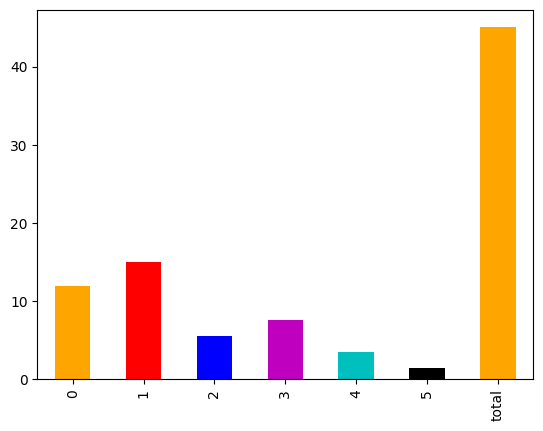

In [16]:
df['2009'].plot(kind='bar', color=('orange','r', 'b', 'm', 'c', 'k'))

<Axes: ylabel='2009'>

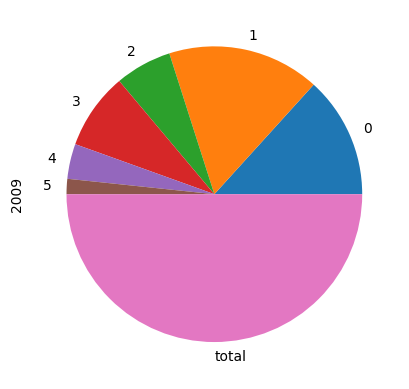

In [17]:
df['2009'].plot(kind='pie')

<Axes: >

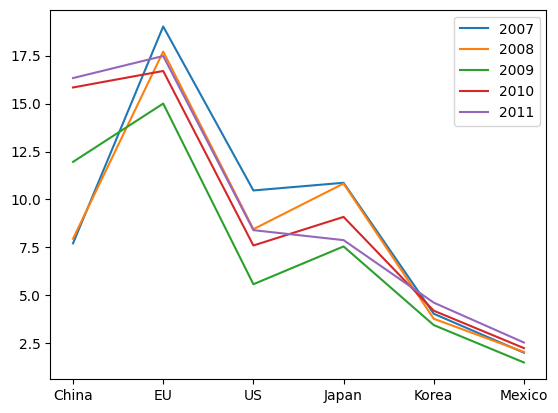

In [18]:
file = './vehicle_prod.csv'
df = pd.read_csv(file, index_col=0)
df.plot.line()


         2007   2008   2009   2010   2011
China    7.71   7.95  11.96  15.84  16.33
EU      19.02  17.71  15.00  16.70  17.48
US      10.47   8.45   5.58   7.60   8.40
Japan   10.87  10.83   7.55   9.09   7.88
Korea    4.04   3.78   3.45   4.20   4.62
Mexico   2.01   2.05   1.50   2.25   2.54


<Axes: >

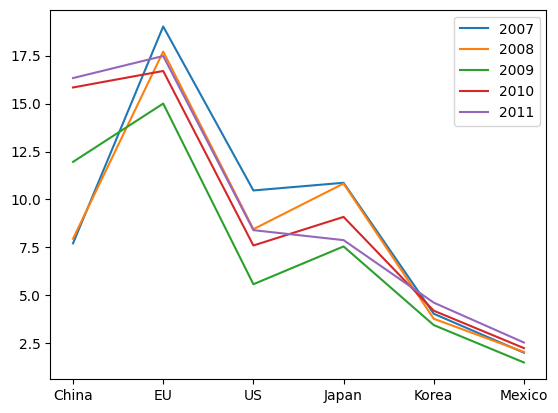

In [20]:
df = df.transpose()  # df = df.T도 가능함
#df = df.T
print(df)
df.plot.line()

In [28]:
file = './vehicle_prod.csv'
df = pd.read_csv(file, index_col=0)   # 원격지에 접속하여 csv를 읽어옴
#df.head(3)     # 첫 3행의 정보를 가져온다
#df.tail(4) # 마지막 3개행의 정보를 가져온다.
df[3:4]

,2007,2008,2009,2010,2011
Japan,10.87,10.83,7.55,9.09,7.88


In [32]:
df.loc["Korea"]

2007    4.04
2008    3.78
2009    3.45
2010    4.20
2011    4.62
Name: Korea, dtype: float64

In [33]:
df.loc[["Korea", 'US']]

,2007,2008,2009,2010,2011
Korea,4.04,3.78,3.45,4.2,4.62
US,10.47,8.45,5.58,7.6,8.40


In [34]:
df['2011'][[0, 4]]

/tmp/ipykernel_31115/2494770783.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['2011'][[0, 4]]


China    16.33
Korea     4.62
Name: 2011, dtype: float64

In [35]:
df.loc['Korea', '2011']

np.float64(4.62)

In [37]:
df.loc['Korea'], ['2011']

(2007    4.04
 2008    3.78
 2009    3.45
 2010    4.20
 2011    4.62
 Name: Korea, dtype: float64,
 ['2011'])

In [40]:
df.loc[['Korea'], ['2011']]

,2011
Korea,4.62


In [41]:
df.iloc[4]

2007    4.04
2008    3.78
2009    3.45
2010    4.20
2011    4.62
Name: Korea, dtype: float64

In [42]:
df = pd.read_csv(file, index_col=0)
df.head(3)['2009']     # 첫 3행의 정보를 가져온다

China    11.96
EU       15.00
US        5.58
Name: 2009, dtype: float64

In [43]:
df.iloc[[2, 4]]  # 주의: df.iloc[2, 4]는 US행의 2011년 데이터임

,2007,2008,2009,2010,2011
US,10.47,8.45,5.58,7.6,8.40
Korea,4.04,3.78,3.45,4.2,4.62


In [58]:
weather_file = './weather.csv'

weather = pd.read_csv(weather_file, index_col = 0, encoding='CP949')
print(weather.head(3))
print('weather 데이터의 shape :', weather.shape)


            평균기온  최대풍속  평균풍속
일시                          
2010-08-01  28.7   8.3   3.4
2010-08-02  25.2   8.7   3.8
2010-08-03  22.1   6.3   2.9
weather 데이터의 shape : (3653, 3)


In [47]:
print(weather.describe().round(2))

          평균기온     최대풍속     평균풍속
count  3653.00  3649.00  3647.00
mean     12.94     7.91     3.94
std       8.54     3.03     1.89
min      -9.00     2.00     0.20
25%       5.40     5.70     2.50
50%      13.80     7.60     3.60
75%      20.10     9.70     5.00
max      31.30    26.00    14.90


In [49]:
weather.isna()

,평균기온,최대풍속,평균풍속
일시,,,
2010-08-01,False,False,False
2010-08-02,False,False,False
2010-08-03,False,False,False
2010-08-04,False,False,False
2010-08-05,False,False,False
...,...,...,...
2020-07-27,False,False,False
2020-07-28,False,False,False
2020-07-29,False,False,False


In [52]:
weather[weather.isna().any(axis=1)]

,평균기온,최대풍속,평균풍속
일시,,,
2012-02-11,-0.7,NaN,NaN
2012-02-12,0.4,NaN,NaN
2012-02-13,4.0,NaN,NaN
2015-03-22,10.1,11.6,NaN
2015-04-01,7.3,12.1,NaN
2019-04-18,15.7,11.7,NaN
2019-04-19,7.8,NaN,2.3


In [53]:
weather.count()

평균기온    3653
최대풍속    3649
평균풍속    3647
dtype: int64

In [54]:
missing_data = weather[ weather['평균풍속'].isna() ]
print(missing_data)

            평균기온  최대풍속  평균풍속
일시                          
2012-02-11  -0.7   NaN   NaN
2012-02-12   0.4   NaN   NaN
2012-02-13   4.0   NaN   NaN
2015-03-22  10.1  11.6   NaN
2015-04-01   7.3  12.1   NaN
2019-04-18  15.7  11.7   NaN


In [55]:
# 데이터셋을 받아온 후 아래 코드로 결손값이 포함된 행 제거
weather.dropna(axis=0, how='any', inplace=True)
missing_data = weather[weather['평균풍속'].isna()]

print(missing_data)
print(weather[weather.isna().any(axis=1)])
weather.describe()

Empty DataFrame
Columns: [평균기온, 최대풍속, 평균풍속]
Index: []
Empty DataFrame
Columns: [평균기온, 최대풍속, 평균풍속]
Index: []


,평균기온,최대풍속,평균풍속
count,3646.000000,3646.000000,3646.000000
mean,12.954717,7.907899,3.936890
std,8.538707,3.029047,1.888538
min,-9.000000,2.000000,0.200000
25%,5.400000,5.700000,2.500000
50%,13.800000,7.600000,3.600000
75%,20.100000,9.700000,5.000000
max,31.300000,26.000000,14.900000


In [61]:
new_weather=weather.fillna( weather['평균풍속'].mean(), inplace = False)
new_weather.describe()

,평균기온,최대풍속,평균풍속
count,3653.000000,3653.000000,3653.000000
mean,12.942102,7.906747,3.936441
std,8.538507,3.031055,1.886922
min,-9.000000,2.000000,0.200000
25%,5.400000,5.600000,2.500000
50%,13.800000,7.600000,3.600000
75%,20.100000,9.700000,5.000000
max,31.300000,26.000000,14.900000


In [62]:
new_weather=weather.fillna( 0, inplace = False)
new_weather.describe()

,평균기온,최대풍속,평균풍속
count,3653.000000,3653.000000,3653.000000
mean,12.942102,7.902436,3.929975
std,8.538507,3.039488,1.893644
min,-9.000000,0.000000,0.000000
25%,5.400000,5.600000,2.500000
50%,13.800000,7.600000,3.600000
75%,20.100000,9.700000,5.000000
max,31.300000,26.000000,14.900000


In [63]:
import pandas as pd

# 다양한 형식의 연,월,일 표시 데이터
d_list = ["01/03/2018", "01-03-2018", "2018-01-05", "2018/01/06"]
pd.DatetimeIndex(d_list).year    # 년도 값을 출력함

Index([2018, 2018, 2018, 2018], dtype='int32')

In [64]:
dt_list = ["01,03,2018 11:12:13", "01-03-2018 11:22:13"]
pd.DatetimeIndex(dt_list).hour     # 시 값을 출력함

Index([11, 11], dtype='int32')

In [65]:
weather_file = './weather.csv'

weather = pd.read_csv(weather_file, encoding='CP949')
weather['일시'] = pd.DatetimeIndex(weather['일시']).year
weather

,일시,평균기온,최대풍속,평균풍속
0,2010,28.7,8.3,3.4
1,2010,25.2,8.7,3.8
2,2010,22.1,6.3,2.9
3,2010,25.3,6.6,4.2
4,2010,27.2,9.1,5.6
...,...,...,...,...
3648,2020,22.1,4.2,1.7
3649,2020,21.9,4.5,1.6
3650,2020,21.6,3.2,1.0
3651,2020,22.9,9.7,2.4


            평균기온      최대풍속      평균풍속
month                               
1       1.598387  8.158065  3.757419
2       2.136396  8.225357  3.946786
3       6.250323  8.871935  4.390291
4      11.064667  9.305017  4.622483
5      16.564194  8.548710  4.219355
6      19.616667  6.945667  3.461000
7      23.328387  7.322581  3.877419
8      24.748710  6.853226  3.596129
9      20.323667  6.896333  3.661667
10     15.383871  7.766774  3.961613
11      9.889667  8.013333  3.930667
12      3.753548  8.045484  3.817097


<Axes: xlabel='month'>

/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missin

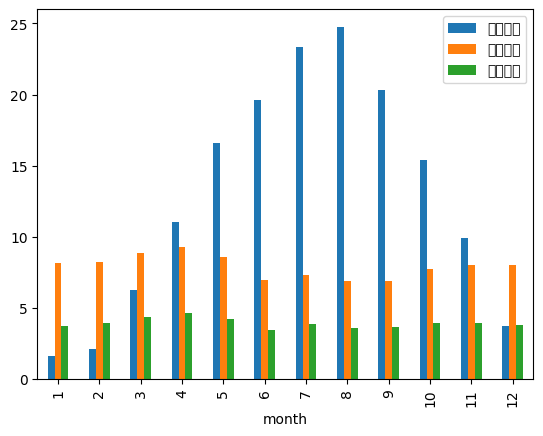

In [81]:
weather_file = './weather.csv'

weather = pd.read_csv(weather_file, encoding='CP949')
weather['month'] = pd.DatetimeIndex(weather['일시']).month

# numeric_only = True라는 키워드 인자를 통해서 일시 열을 계산에서 제외
# 'month'를 기준으로 묶고 평균을 구함
monthly_means = weather.groupby('month').mean(numeric_only = True)
print(monthly_means)    # 그룹으로 묶인 'month' 데이터를 기준으로 평균값을 출력한다

monthly_means.plot(kind='bar')

In [85]:
weather_file = './weather.csv'
weather = pd.read_csv(weather_file, encoding='CP949')

weather['year'] = pd.DatetimeIndex(weather['일시']).year
print(weather)
y_means = weather.groupby('year').mean(numeric_only=True)
print(y_means)

y_max = weather.groupby('year').max(numeric_only=True)
print(y_max)

              일시  평균기온  최대풍속  평균풍속  year
0     2010-08-01  28.7   8.3   3.4  2010
1     2010-08-02  25.2   8.7   3.8  2010
2     2010-08-03  22.1   6.3   2.9  2010
3     2010-08-04  25.3   6.6   4.2  2010
4     2010-08-05  27.2   9.1   5.6  2010
...          ...   ...   ...   ...   ...
3648  2020-07-27  22.1   4.2   1.7  2020
3649  2020-07-28  21.9   4.5   1.6  2020
3650  2020-07-29  21.6   3.2   1.0  2020
3651  2020-07-30  22.9   9.7   2.4  2020
3652  2020-07-31  25.7   4.8   2.5  2020

[3653 rows x 5 columns]
           평균기온      최대풍속      평균풍속
year                               
2010  15.238562  8.205229  4.069281
2011  12.073425  8.355616  4.251233
2012  11.892896  7.794490  3.863912
2013  12.795068  7.859726  3.874795
2014  12.844110  7.458904  3.816438
2015  13.162466  7.694247  3.799449
2016  13.243443  7.963934  3.977869
2017  13.111233  8.001370  3.934795
2018  13.041644  8.158630  4.085479
2019  13.767671  7.796703  3.854396
2020  12.233333  7.897183  3.786385
      평균기온  최대풍

In [91]:
monthly_means[ monthly_means['평균풍속'] >= 4.0 ]
monthly_means['평균풍속'] >= 4.0

month
1     False
2     False
3      True
4      True
5      True
6     False
7     False
8     False
9     False
10    False
11    False
12    False
Name: 평균풍속, dtype: bool

In [90]:
#print(monthly_means)
monthly_means

,평균기온,최대풍속,평균풍속
month,,,
1,1.598387,8.158065,3.757419
2,2.136396,8.225357,3.946786
3,6.250323,8.871935,4.390291
4,11.064667,9.305017,4.622483
5,16.564194,8.548710,4.219355
6,19.616667,6.945667,3.461000
7,23.328387,7.322581,3.877419
8,24.748710,6.853226,3.596129
9,20.323667,6.896333,3.661667


In [92]:
import pandas as pd

df = pd.DataFrame({'상품' : ['시계', '반지', '반지', '목걸이', '팔찌'],
                   '재질' : ['금', '은', '백금', '금', '은'],
                   '가격': [500000, 20000, 350000, 300000, 60000]})
df

,상품,재질,가격
0,시계,금,500000
1,반지,은,20000
2,반지,백금,350000
3,목걸이,금,300000
4,팔찌,은,60000


In [94]:
df.iloc[0,2]

np.int64(500000)

In [95]:
new_df = df.pivot(index='상품', columns='재질', values='가격')
new_df.fillna(value=0)

재질,금,백금,은
상품,,,
목걸이,300000.0,0.0,0.0
반지,0.0,350000.0,20000.0
시계,500000.0,0.0,0.0
팔찌,0.0,0.0,60000.0


In [96]:
import pandas as pd

df_1 = pd.DataFrame( {'A' : ['a10', 'a11', 'a12'],
                      'B' : ['b10', 'b11', 'b12'],
                      'C' : ['c10', 'c11', 'c12']} ,
                      index = ['가', '나',  '다'] )

df_2 = pd.DataFrame( {'B' : ['b23', 'b24', 'b25'],
                      'C' : ['c23', 'c24', 'c25'],
                      'D' : ['d23', 'd24', 'd25']} ,
                      index = ['다', '라',  '마'] )

In [97]:
df_1

,A,B,C
가,a10,b10,c10
나,a11,b11,c11
다,a12,b12,c12


In [98]:
df_2

,B,C,D
다,b23,c23,d23
라,b24,c24,d24
마,b25,c25,d25


In [99]:
df_3 = pd.concat( [df_1, df_2])
print(df_3)

     A    B    C    D
가  a10  b10  c10  NaN
나  a11  b11  c11  NaN
다  a12  b12  c12  NaN
다  NaN  b23  c23  d23
라  NaN  b24  c24  d24
마  NaN  b25  c25  d25


In [100]:
df_4 = pd.concat( [df_1, df_2], join='inner')
print(df_4)

     B    C
가  b10  c10
나  b11  c11
다  b12  c12
다  b23  c23
라  b24  c24
마  b25  c25


In [ ]:
pi